Modelling

Hypothesis 1:
Higher BMI increases the probability of diabetes.

Hypothesis 2:
Poor general health is strongly associated with diabetes risk.

Hypothesis 3:
Older individuals are more likely to develop diabetes.

STEP 1 — LOAD CLEANED DATA

In [5]:
import pandas as pd

url = "https://drive.google.com/uc?export=download&id=1KM7-w5Zw6yPguF25fk_ois0CM_G30DQ9"

df = pd.read_csv(url)

print(df.shape)
print(df.head())

(229781, 23)
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  NoDocbcCost  GenHlth  \
0                   0.0           0.0     0.0  ...          0.0      5.0   
1                   0.0           1.0     0.0  ...          1.0      3.0   
2                   0.0           0.0     1.0  ...          1.0      5.0   
3                   0.0           1.0     1.0  ...          0.0      2.0   
4                   0.0           1.0     1.0  ...          0.0      2.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  Income  BMI_cat  
0      18.0      15.0       1.0  0.0

STEP 2 — DEFINE FEATURES & TARGET

In [6]:
X = df.drop("Diabetes_012", axis=1)

y = df["Diabetes_012"]

STEP 3 — SELECT ANALYTICAL MODELS



1.problem type,
2.explainability,
3.computational resources,
4.data characteristics.

Problem Type

 Multiclass Classification

because:

0 = No Diabetes
1 = Prediabetes
2 = Diabetes

STEP 4 — TRAIN-TEST SPLIT

In [7]:
!pip install scikit-learn
!pip install scikit-learn imbalanced-learn xgboost seaborn joblib

In [8]:
from sklearn.model_selection import train_test_split

FEATURE SELECTION EXPERIMENTS

In [9]:
X = df.drop("Diabetes_012", axis=1)

Remove Weak Features

In [10]:
drop_cols = [
    'CholCheck',
    'AnyHealthcare',
    'Sex'
]

X = df.drop(drop_cols + ['Diabetes_012'], axis=1)

Install libraries

In [11]:
!pip install scikit-learn imbalanced-learn xgboost seaborn joblib

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

load Clean Data

In [13]:
url = "https://drive.google.com/uc?export=download&id=1KM7-w5Zw6yPguF25fk_ois0CM_G30DQ9"

df = pd.read_csv(url)

Define features and target

In [14]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

Split data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Apply SMOTE

In [16]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

Scale features

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

Train Logistic Regression

In [18]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)

In [19]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.94      0.64      0.76     38012
         1.0       0.03      0.31      0.06       926
         2.0       0.37      0.59      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.51      0.42     45957
weighted avg       0.84      0.63      0.70     45957



DECISION TREE MODEL

In [20]:
from sklearn.tree import DecisionTreeClassifier

Train Decision Tree

In [21]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

Make Predictions

In [22]:
y_pred_dt = dt.predict(X_test)

Evaluate Decision Tree

In [23]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:
0.7418456383140762

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85     38012
         1.0       0.02      0.03      0.03       926
         2.0       0.29      0.32      0.30      7019

    accuracy                           0.74     45957
   macro avg       0.39      0.40      0.39     45957
weighted avg       0.76      0.74      0.75     45957



Confusion Matrix

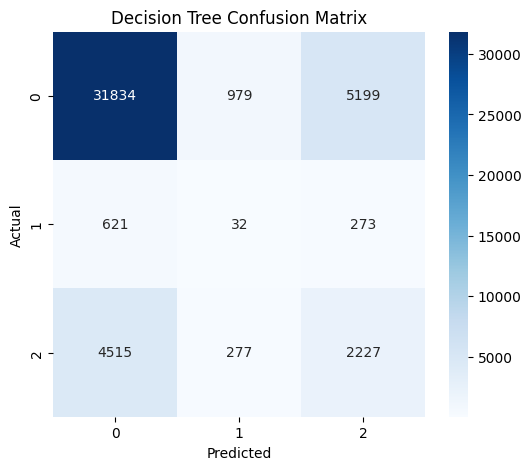

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Import Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

Train Random Forest

In [26]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

Make Predictions

In [27]:
y_pred_rf = rf.predict(X_test)

Evaluate Random Forest

In [28]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.8192223165132624

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.95      0.90     38012
         1.0       0.00      0.00      0.00       926
         2.0       0.44      0.22      0.29      7019

    accuracy                           0.82     45957
   macro avg       0.43      0.39      0.40     45957
weighted avg       0.77      0.82      0.79     45957



Confusion Matrix

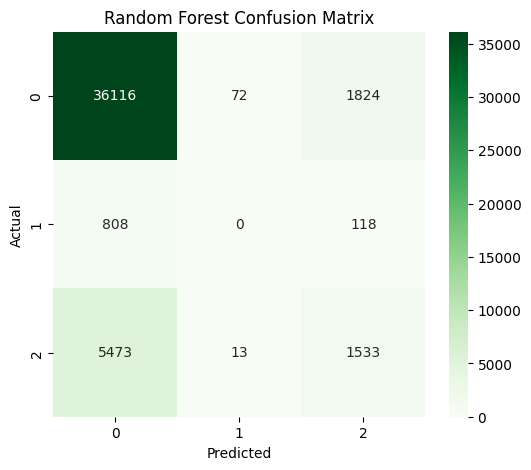

In [29]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Install XGBoost

In [30]:
!pip install xgboost

In [31]:
from xgboost import XGBClassifier

Train XGBoost

In [32]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

Make Predictions

In [33]:
y_pred_xgb = xgb.predict(X_test)

Evaluate XGBoost

In [34]:
print("XGBoost Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy:
0.8346933002589377

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91     38012
         1.0       0.00      0.00      0.00       926
         2.0       0.53      0.25      0.34      7019

    accuracy                           0.83     45957
   macro avg       0.46      0.40      0.42     45957
weighted avg       0.79      0.83      0.80     45957



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

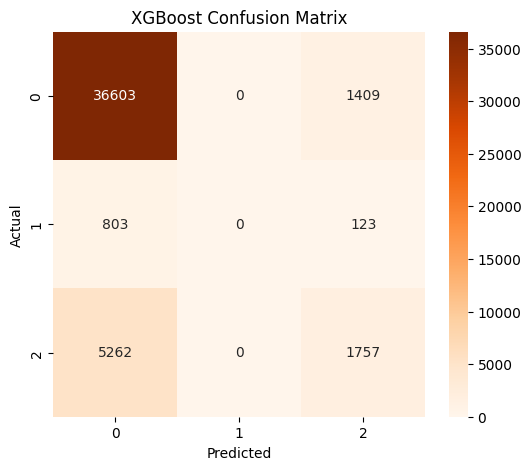

In [35]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

MODEL COMPARISON TABLE


In [36]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
}

Create Comparison Table

In [37]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,Logistic Regression,0.625650
1,Decision Tree,0.741846
2,Random Forest,0.819222
3,XGBoost,0.834693


Sort by Accuracy

In [38]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
3,XGBoost,0.834693
2,Random Forest,0.819222
1,Decision Tree,0.741846
0,Logistic Regression,0.625650


FEATURE IMPORTANCE

Random Forest Feature Importanc

In [39]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

Sort Features

In [40]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,BMI,0.101471
18,Age,0.096058
13,GenHlth,0.095811
0,HighBP,0.083999
1,HighChol,0.075584
20,Income,0.073237
19,Education,0.059030
15,PhysHlth,0.050047
17,Sex,0.044650
4,Smoker,0.043569


Visualize Top Features

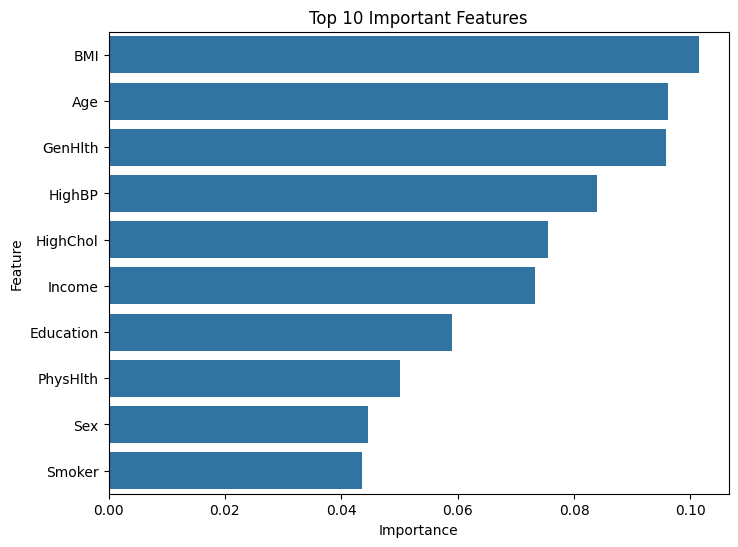

In [41]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

EXPECTED IMPORTANT FEATURES

Based on your Milestone II report:

Likely top features:

GenHlth,
BMI,
HighBP,
Age,
DiffWalk,
HighCho,

HYPERPARAMETER TUNING

In [42]:
from sklearn.model_selection import GridSearchCV

Create Parameter Grid

In [43]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

Run Grid Search

In [45]:
param_grid = {
    'n_estimators': [50],
    'max_depth': [10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10], 'n_estimators': [50]},
             scoring='f1_weighted')

Best Parameters

In [46]:
print("Best Parameters:")

print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 50}


Best **Score**

In [47]:
print("Best Score:")

print(grid.best_score_)

Best Score:
0.6969672234050934


TRAIN FINAL OPTIMIZED MODEL

In [48]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

Final Evaluation

In [49]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88     38012
         1.0       0.03      0.00      0.00       926
         2.0       0.40      0.51      0.45      7019

    accuracy                           0.79     45957
   macro avg       0.44      0.46      0.44     45957
weighted avg       0.80      0.79      0.80     45957



Save Model

In [50]:
import joblib

joblib.dump(best_rf, "best_random_forest.pkl")

['best_random_forest.pkl']

OVERFITTING CHECK

In [51]:
train_score = best_rf.score(
    X_train_smote,
    y_train_smote
)

test_score = best_rf.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_score)

print("Testing Accuracy:", test_score)

Training Accuracy: 0.7252049310611691
Testing Accuracy: 0.7946341144983354


FEATURE IMPORTANCE

In [53]:
importance = best_rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

Sort Features

In [54]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,HighBP,0.205256
1,HighChol,0.191613
13,GenHlth,0.154435
18,Age,0.051637
17,Sex,0.046357
16,DiffWalk,0.044800
3,BMI,0.040950
4,Smoker,0.040307
8,Fruits,0.039847
7,PhysActivity,0.030113


Visualization

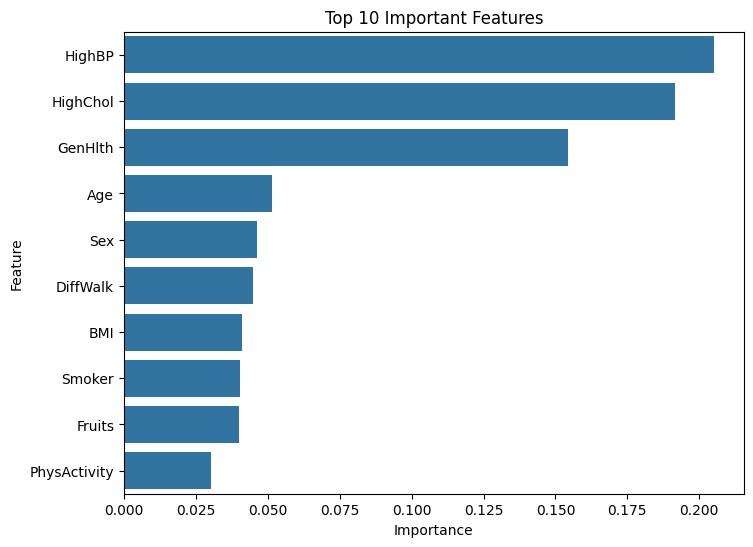

In [55]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

MODEL COMPARISON TABLE

In [57]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Optimized Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best)
    ]
}
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,Logistic Regression,0.625650
1,Decision Tree,0.741846
2,Random Forest,0.819222
3,XGBoost,0.834693
4,Optimized Random Forest,0.794634


Sort Results

In [58]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
3,XGBoost,0.834693
2,Random Forest,0.819222
4,Optimized Random Forest,0.794634
1,Decision Tree,0.741846
0,Logistic Regression,0.625650


visulisation result

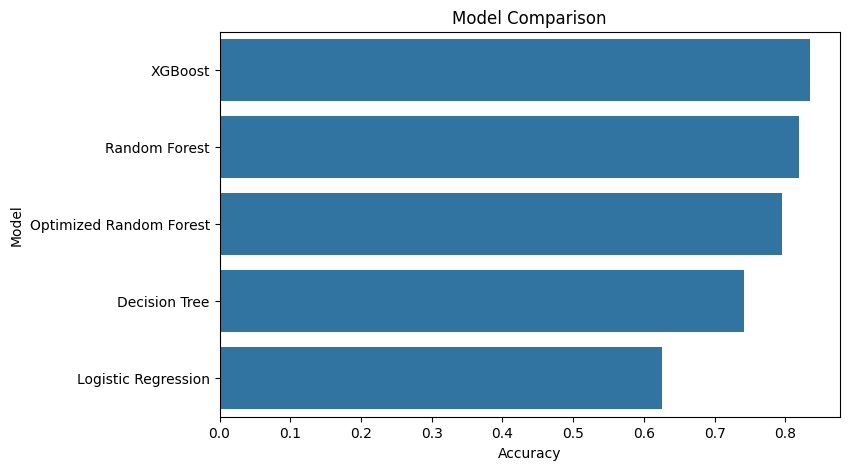

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df
)

plt.title("Model Comparison")

plt.show()

CONFUSION MATRIX FOR BEST MODEL

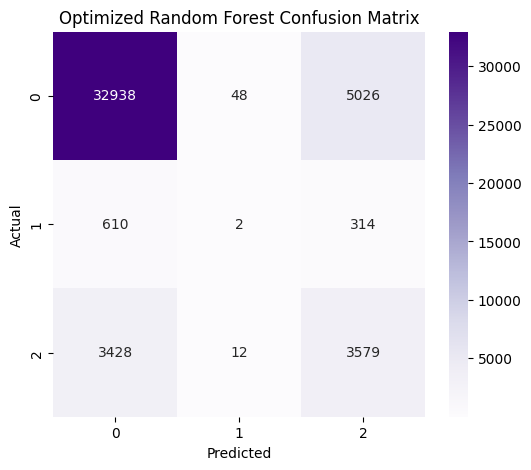

In [60]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Optimized Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
